In [2]:
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from pathlib import Path

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [4]:
DATASET_PATH = Path("../datasets/raw/biodegradable_fabrics")

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
dataset = datasets.ImageFolder(DATASET_PATH)

print(dataset.classes)

['Abaca', 'Cotton', 'Hessian', 'Linen', 'Silk', 'Wool']


In [7]:
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))
labels = [label for _, label in dataset.samples]

# 70% train, 30% temporary
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

# Split remaining 30% into 15% validation and 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print(f"Training Images   : {len(train_idx)}")
print(f"Validation Images : {len(val_idx)}")
print(f"Testing Images    : {len(test_idx)}")

Training Images   : 630
Validation Images : 135
Testing Images    : 135


In [8]:
class TransformedSubset(torch.utils.data.Dataset):

    def __init__(self, subset, transform):

        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):

        image, label = self.subset[idx]

        image = self.transform(image)

        return image, label

In [9]:
train_dataset = TransformedSubset(
    Subset(dataset, train_idx),
    train_transform
)

val_dataset = TransformedSubset(
    Subset(dataset, val_idx),
    test_transform
)

test_dataset = TransformedSubset(
    Subset(dataset, test_idx),
    test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders Ready!")

DataLoaders Ready!


In [10]:
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

In [11]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, len(dataset.classes))
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=1280, out_features=6, bias=True)
  )
)


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

In [13]:
# Freeze everything first
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze ONLY the last EfficientNet feature block
for param in model.features[-1].parameters():
    param.requires_grad = True

# Train classifier
for param in model.classifier.parameters():
    param.requires_grad = True

print("Last feature block is trainable.")
print("Classifier is trainable.")

Last feature block is trainable.
Classifier is trainable.


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [16]:
NUM_EPOCHS = 20

best_accuracy = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [17]:
for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "../models/fabric_classifier.pth"
        )

        print("Best model saved.")

Epoch 1/20 | Train Loss: 1.6889 | Train Acc: 0.3032 | Val Loss: 1.5969 | Val Acc: 0.5037
Best model saved.
Epoch 2/20 | Train Loss: 1.3650 | Train Acc: 0.6794 | Val Loss: 1.3010 | Val Acc: 0.8074
Best model saved.
Epoch 3/20 | Train Loss: 1.0982 | Train Acc: 0.8270 | Val Loss: 1.1075 | Val Acc: 0.8444
Best model saved.
Epoch 4/20 | Train Loss: 0.9047 | Train Acc: 0.8873 | Val Loss: 0.9356 | Val Acc: 0.8963
Best model saved.
Epoch 5/20 | Train Loss: 0.7593 | Train Acc: 0.9079 | Val Loss: 0.8162 | Val Acc: 0.9111
Best model saved.
Epoch 6/20 | Train Loss: 0.6877 | Train Acc: 0.9000 | Val Loss: 0.7150 | Val Acc: 0.9407
Best model saved.
Epoch 7/20 | Train Loss: 0.5621 | Train Acc: 0.9286 | Val Loss: 0.6370 | Val Acc: 0.9630
Best model saved.
Epoch 8/20 | Train Loss: 0.4860 | Train Acc: 0.9413 | Val Loss: 0.5839 | Val Acc: 0.9630
Epoch 9/20 | Train Loss: 0.4361 | Train Acc: 0.9381 | Val Loss: 0.5136 | Val Acc: 0.9556
Epoch 10/20 | Train Loss: 0.3975 | Train Acc: 0.9365 | Val Loss: 0.4650 |

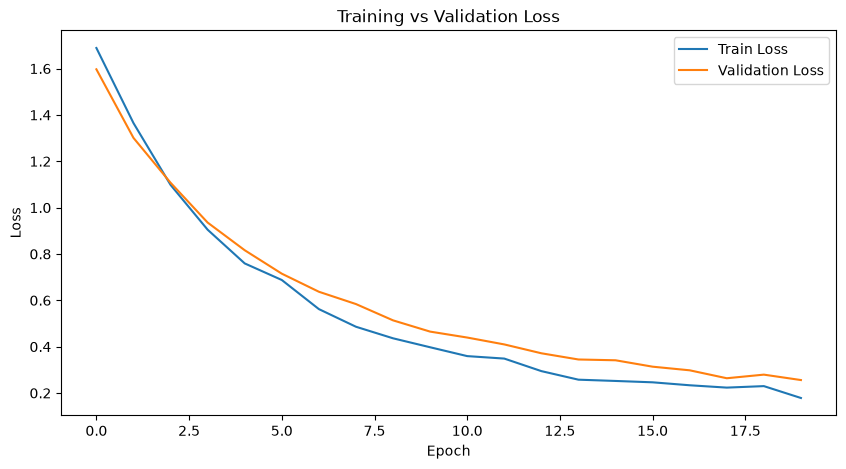

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

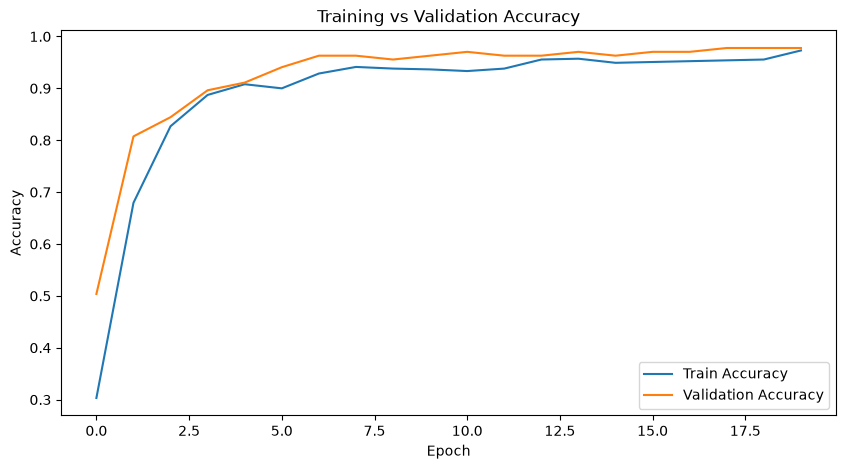

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [20]:
from pathlib import Path

model_path = Path("../models/fabric_classifier.pth")

print(model_path.exists())
print(model_path)

True
..\models\fabric_classifier.pth


In [21]:
import os

model_path = "../models/fabric_classifier.pth"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Size (bytes):", os.path.getsize(model_path))

Exists: True
Size (bytes): 16358075


In [22]:
torch.save(model.state_dict(), "../models/test_model.pth")

In [23]:
import os

print("Test model size:", os.path.getsize("../models/test_model.pth"))

Test model size: 16355449
